# Erken Evre Alzheimer Tespiti - Piksel ve Filtreleme İşlemleri

**Projenin Amacı:** Beyin MRI görüntülerine bakarak hastada erken evre Alzheimer olup olmadığını derin öğrenme modelleriyle yüksek doğrulukla tespit etmek.

Bu ödevde, veri setimizden (`data` klasöründen) aldığımız örnek bir beyin MRI görüntüsü üzerinde **piksel (noktasal)** ve **filtreleme (mekansal)** işlemleri yapacağız. Bu işlemler sayesinde görüntüyü modelimizin (yapay zeka) daha kolay anlayabileceği ve öğrenebileceği bir formata getirmiş olacağız.

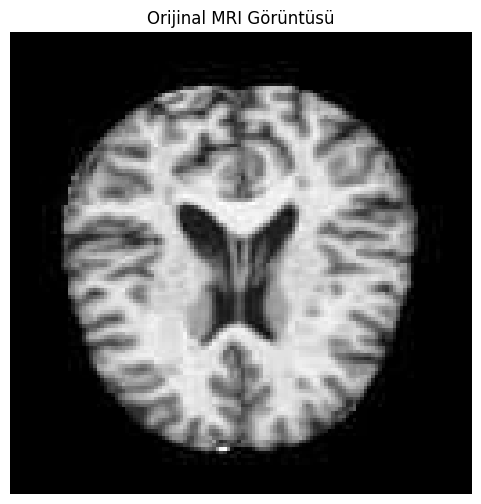

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Örnek MRI görüntümüzü okuyoruz (siyah beyaz - grayscale formatında)
img = cv2.imread('ornek_mri.jpg', cv2.IMREAD_GRAYSCALE)

# Orijinal görüntüyü ekrana çizdirelim
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Orijinal MRI Görüntüsü')
plt.axis('off')
plt.show()

## 1. Piksel İşlemleri: Normalizasyon ve Histogram Eşitleme

Alzheimer hastalığı beynin küçülmesine (atrofi), sıvı dolu boşlukların (ventriküllerin) büyümesine neden olur. Ancak MRI çekimlerinde gri madde, beyaz madde ve beyin omurilik sıvısı arasındaki ton farkları bazen çok belirsiz olabilir.

Burada **Histogram Eşitleme (Kontrast Artırma)** yapacağız. 
**Ana Hedefe Katkısı:** Karanlık veya soluk çıkmış bölgelerdeki zıtlığı (kontrastı) artırarak, beynin içindeki yapısal bozulmaları (dokular arasındaki farkları) modelimizin daha rahat görmesini (ayırt etmesini) sağlayacağız.

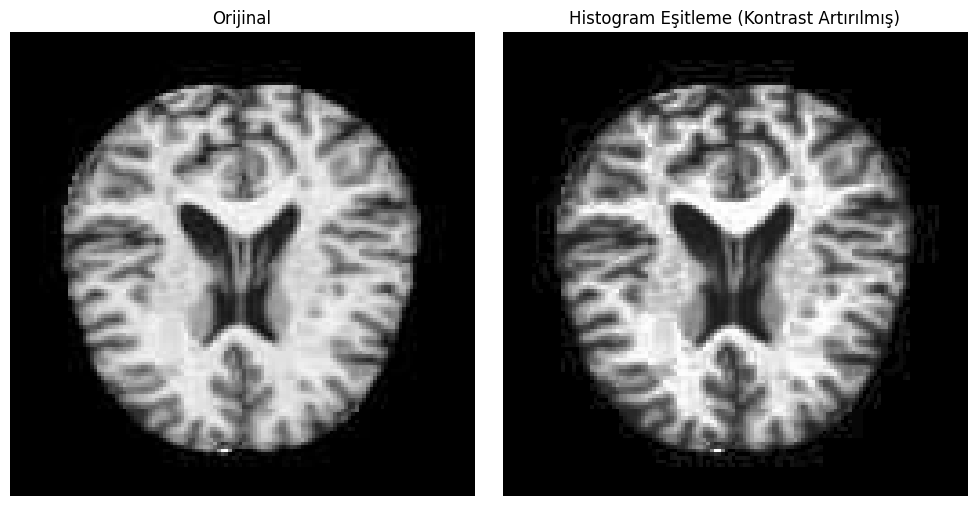

In [2]:
# Histogram Eşitleme İşlemi (Kontrastı artırmak için)
img_eq = cv2.equalizeHist(img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Orijinal')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_eq, cmap='gray')
plt.title('Histogram Eşitleme (Kontrast Artırılmış)')
plt.axis('off')

plt.tight_layout()
plt.show()

Buna ek olarak, derin öğrenme modellerinin eğitimi sırasında büyük sayılar (0-255 arası piksel değerleri) modeli yorabilir. Bu sebeple görüntüleri 0 ile 1 arasına sıkıştıran **Min-Max Normalizasyonu** da sıkça kullanılır. Bu sayede model çok daha hızlı ve kararlı öğrenir.

In [4]:
# Piksel Normalizasyonu (0 ile 1 aralığına çekme)
img_normalized = img_eq / 255.0

print(f"Orijinal min-max değerleri: {img.min()} - {img.max()}")
print(f"Normalize sonrası min-max değerleri: {img_normalized.min()} - {img_normalized.max()}")

Orijinal min-max değerleri: 0 - 157
Normalize sonrası min-max değerleri: 0.0 - 1.0


## 2. Filtreleme İşlemleri: Gürültü Azaltma (Gaussian Blur) ve Kenar Çıkarma (Sobel)

MRI cihazlarından kaynaklı görüntüde bazen "kumlanmalar" (gürültü - noise) olabilir. Bu kumlanmalar modelin kafasını karıştırıp yanlış yerlere odaklanmasına neden olabilir. Noktasal olmayan, çevredeki pikselleri hesaba katan **Gaussian Blur** filtresi uygulayacağız.

**Ana Hedefe Katkısı:** Görüntüyü hafifçe bulanıklaştırarak gereksiz kumlardan arındırırız. Modelimiz sadece gerçek anatomik (beyin) yapılarına odaklanır.

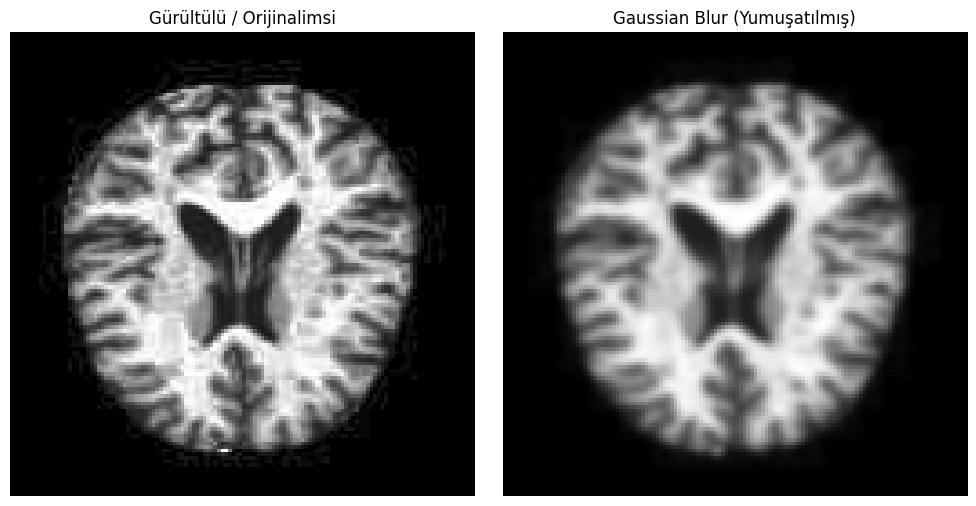

In [3]:
# Gaussian Blur ile gürültü azaltma (Önceki normalize edilmemiş eşitlenmiş resmi kullanıyoruz)
# 5x5 boyutunda bir çekirdek (kernel) filtre ile komşu pikseller hesaplanıyor
img_blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_eq, cmap='gray')
plt.title('Gürültülü / Orijinalimsi')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_blurred, cmap='gray')
plt.title('Gaussian Blur (Yumuşatılmış)')
plt.axis('off')

plt.tight_layout()
plt.show()

Son olarak, boşlukların (ventriküllerin) sınırlarını ve beyin kıvrımlarını (sulkus) belirginleştirmek için bir **Kenar Bulma (Edge Detection)** filtresi olan **Sobel** uygulayabiliriz.

**Ana Hedefe Katkısı:** Alzheimer, bu sınırların genişlemesine sebep olur. Sınırları birer çizgi şeklinde ortaya çıkardığımızda, yapay zeka yapısal deformasyonu matematiksel olarak çok daha net algılayabilir.

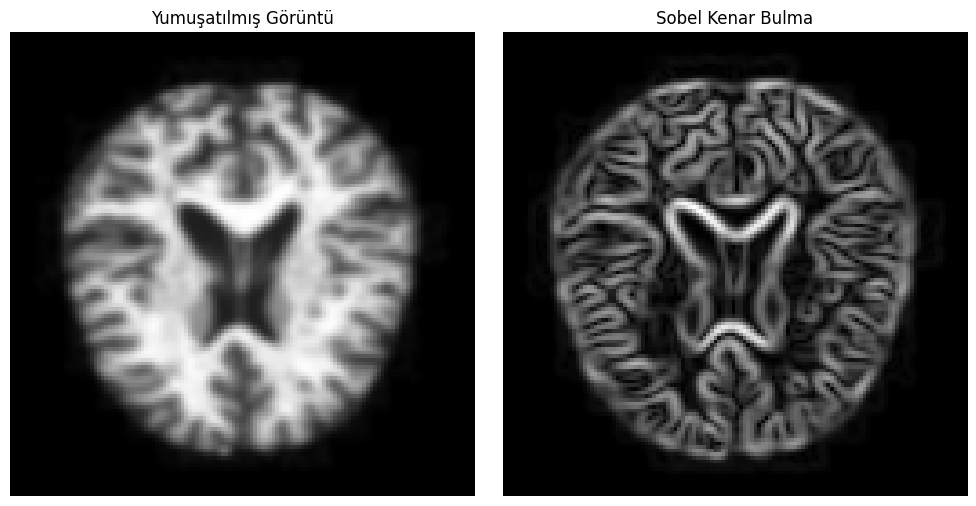

In [5]:
# Sobel filtresi ile kenar hatlarını bulma (Yumuşatılmış resim üzerinden yapıyoruz ki kumları kenar sanmasın)
sobel_x = cv2.Sobel(img_blurred, cv2.CV_64F, 1, 0, ksize=3) # Yatay kenarlar
sobel_y = cv2.Sobel(img_blurred, cv2.CV_64F, 0, 1, ksize=3) # Dikey kenarlar
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_blurred, cmap='gray')
plt.title('Yumuşatılmış Görüntü')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Kenar Bulma')
plt.axis('off')

plt.tight_layout()
plt.show()

### Sonuç
Bu ödevde;
1. **Histogram Eşitleme (Piksel İşlemi)** ile doku kontrastını artırdık.
2. **Normalizasyon (Piksel İşlemi)** ile yapay zeka modelinin daha hızlı öğrenmesini sağlayacak formata getirdik.
3. **Gaussian Blur (Filtreleme İşlemi)** ile MR cihazından kaynaklanan kumlamaları giderip, modelin gerçek dokulara odaklanmasını sağladık.
4. **Sobel Filtresi (Filtreleme İşlemi)** ile Alzheimer'da değişikliğe uğrayan beyin yapılarının (ventriküller vb.) kenar hatlarını çizdirerek, modelin yapısal deformasyonu kolayca fark edebileceği hale getirdik.
